# Analisis Komputasi Evolusi Resistansi Antibiotik pada Populasi Bakteri melalui Mekanisme Seleksi Alam

**Topik:** Proses Evolusi dan Seleksi Alam

**Tujuan:** Menganalisis bagaimana resistansi antibiotik berkembang dalam populasi bakteri melalui mekanisme evolusi dan seleksi alam menggunakan pemodelan komputasi.

---

## 1. PENDAHULUAN DAN PERTANYAAN PENELITIAN

### 1.1 Latar Belakang

Resistansi antibiotik adalah salah satu ancaman kesehatan global yang paling signifikan. Fenomena ini terjadi melalui proses evolusi dan seleksi alam, di mana bakteri yang memiliki mutasi menguntungkan (gen resistansi) akan terus berkembang biak sementara bakteri yang rentan terhadap antibiotik akan mati.

### 1.2 Pertanyaan Penelitian

1. **Bagaimana frekuensi alel resistansi berubah seiring waktu dalam populasi bakteri yang terkena paparan antibiotik?**
2. **Apa pengaruh intensitas paparan antibiotik terhadap kecepatan evolusi resistansi?**
3. **Bagaimana dinamika populasi bakteri sensitif vs. resisten dalam model seleksi alam?**
4. **Apakah ada hubungan kuadratik antara konsentrasi antibiotik dan tingkat kelangsungan hidup bakteri?**

### 1.3 Hipotesis

- Bakteri dengan alel resistansi akan meningkat frekuensinya secara eksponensial ketika terdapat paparan antibiotik
- Semakin tinggi konsentrasi antibiotik, semakin cepat seleksi terhadap alel resistansi
- Populasi akan mencapai equilibrium ketika hampir semua individu memiliki gen resistansi

## 2. KONSEP BIOLOGI: DASAR TEORITIS

### 2.1 Evolusi dan Seleksi Alam

**Teori Darwin:**
- Variasi genetik dalam populasi
- Kompetisi untuk sumber daya
- Survival of the fittest
- Reproduksi diferensial

### 2.2 Genetika Populasi: Hardy-Weinberg Equilibrium

Dalam populasi yang ideal tanpa seleksi:
- Frekuensi alel tetap konstan antar generasi
- Frekuensi genotip dapat diprediksi dari frekuensi alel
- Formula: **p² + 2pq + q² = 1**

Dimana:
- p = frekuensi alel dominan (sensitif terhadap antibiotik)
- q = frekuensi alel resesif (resisten terhadap antibiotik)

### 2.3 Koefisien Seleksi (Selection Coefficient)

Dalam populasi dengan seleksi:
- **s** = koefisien seleksi (0 ≤ s ≤ 1)
- s = 0: tidak ada seleksi
- s = 1: seleksi absolut (alel lain hilang)
- **w = 1 - s**: fitness relatif dari genotip

### 2.4 Resistansi Antibiotik pada Bakteri

**Mekanisme:**
1. **Mutasi spontan** menghasilkan gen resistansi
2. **Paparan antibiotik** menciptakan tekanan seleksi
3. **Bakteri resisten** memiliki fitness lebih tinggi dalam lingkungan dengan antibiotik
4. **Reproduksi diferensial** meningkatkan frekuensi alel resistansi

---

## 3. SETUP DAN IMPORT LIBRARY

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint
from scipy.optimize import curve_fit
import warnings

warnings.filterwarnings('ignore')

# Set random seed untuk reproducibility
np.random.seed(42)

# Style plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Library berhasil diimport!")

Library berhasil diimport!


## 4. MODEL KOMPUTASI: SIMULASI POPULASI BAKTERI

### 4.1 Model Dinamik Populasi dengan Seleksi

In [50]:
class BacterialPopulation:
    """
    Model komputasi populasi bakteri dengan mekanisme seleksi alam.
    
    Parameters:
    -----------
    initial_pop_sensitive : int
        Jumlah awal bakteri sensitif
    initial_pop_resistant : int
        Jumlah awal bakteri resisten
    growth_rate_sensitive : float
        Laju pertumbuhan bakteri sensitif tanpa antibiotik
    growth_rate_resistant : float
        Laju pertumbuhan bakteri resisten
    antibiotic_concentration : float
        Konsentrasi antibiotik (0-1)
    selection_coefficient : float
        Koefisien seleksi terhadap bakteri sensitif
    """
    
    def __init__(self, initial_pop_sensitive=1000, initial_pop_resistant=10,
                 growth_rate_sensitive=0.3, growth_rate_resistant=0.25,
                 antibiotic_concentration=0.5, selection_coefficient=0.8):
        
        self.N_sensitive = initial_pop_sensitive
        self.N_resistant = initial_pop_resistant
        self.r_s = growth_rate_sensitive  # laju pertumbuhan sensitif
        self.r_r = growth_rate_resistant  # laju pertumbuhan resisten
        self.antibiotic = antibiotic_concentration
        self.s = selection_coefficient  # koefisien seleksi
        
        self.history = {
            'time': [],
            'sensitive': [],
            'resistant': [],
            'total': [],
            'freq_resistant': []
        }
    
    def fitness_sensitive(self):
        """
        Hitung fitness bakteri sensitif.
        Fitness menurun dengan adanya antibiotik.
        Menggunakan model Hill curve untuk realistic representation.
        """
        # w = 1 - (s * antibiotic^2) untuk efek non-linear
        w = 1 - (self.s * (self.antibiotic ** 2))
        return max(0, w)  # fitness tidak negatif
    
    def fitness_resistant(self):
        """
        Hitung fitness bakteri resisten.
        Fitness hampir tidak terpengaruh oleh antibiotik.
        Asumsi: ada cost fitness kecil untuk membawa gen resistansi.
        """
        cost_of_resistance = 0.05  # cost fitness 5%
        w = 1 - cost_of_resistance
        return w
    
    def carrying_capacity(self):
        """
        Daya dukung lingkungan (K) untuk menghindari pertumbuhan infinite.
        """
        return 10000  # maksimal populasi
    
    def step(self, dt=1):
        """
        Simulasi satu langkah waktu menggunakan model logistik dengan seleksi.
        
        dN_s/dt = r_s * w_s * N_s * (1 - (N_s + N_r) / K)
        dN_r/dt = r_r * w_r * N_r * (1 - (N_s + N_r) / K)
        """
        K = self.carrying_capacity()
        N_total = self.N_sensitive + self.N_resistant
        
        w_s = self.fitness_sensitive()
        w_r = self.fitness_resistant()
        
        # Model logistik dengan seleksi alam
        dN_s = self.r_s * w_s * self.N_sensitive * (1 - N_total / K) * dt
        dN_r = self.r_r * w_r * self.N_resistant * (1 - N_total / K) * dt
        
        self.N_sensitive = max(0, self.N_sensitive + dN_s)
        self.N_resistant = max(0, self.N_resistant + dN_r)
        
        # Tambahkan stochasticity minimal (mutasi spontan)
        if np.random.random() < 0.01 and self.N_sensitive > 0:
            # 1% dari bakteri sensitif mengalami mutasi menjadi resisten
            mutations = int(0.001 * self.N_sensitive)
            self.N_sensitive -= mutations
            self.N_resistant += mutations
    
    def simulate(self, generations=100, dt=0.5):
        """
        Jalankan simulasi untuk sejumlah generasi.
        """
        for gen in range(generations):
            time = gen * dt
            N_total = self.N_sensitive + self.N_resistant
            freq_resistant = self.N_resistant / N_total if N_total > 0 else 0
            
            # Simpan history
            self.history['time'].append(time)
            self.history['sensitive'].append(self.N_sensitive)
            self.history['resistant'].append(self.N_resistant)
            self.history['total'].append(N_total)
            self.history['freq_resistant'].append(freq_resistant)
            
            # Lakukan satu step simulasi
            self.step(dt=dt)
    
    def get_dataframe(self):
        """
        Kembalikan hasil simulasi sebagai pandas DataFrame.
        """
        return pd.DataFrame(self.history)

print("Class BacterialPopulation berhasil didefinisikan!")

Class BacterialPopulation berhasil didefinisikan!


## 5. SIMULASI DAN DATA GENERATION

### 5.1 Skenario 1: Tanpa Antibiotik (Baseline Control)

In [51]:
# Simulasi tanpa antibiotik (kontrol)
pop_control = BacterialPopulation(
    initial_pop_sensitive=1000,
    initial_pop_resistant=10,
    growth_rate_sensitive=0.3,
    growth_rate_resistant=0.25,
    antibiotic_concentration=0.0,  # TANPA ANTIBIOTIK
    selection_coefficient=0.0
)

pop_control.simulate(generations=150, dt=0.5)
df_control = pop_control.get_dataframe()

print("Skenario Kontrol (Tanpa Antibiotik):")
print(df_control.tail(10))
print(f"\nFrekuensi alel resisten akhir: {df_control['freq_resistant'].iloc[-1]:.4f}")

Skenario Kontrol (Tanpa Antibiotik):
     time    sensitive  resistant        total  freq_resistant
140  70.0  9919.390381  80.609601  9999.999982        0.008061
141  70.5  9919.390384  80.609601  9999.999985        0.008061
142  71.0  9919.390386  80.609601  9999.999987        0.008061
143  71.5  9919.390388  80.609601  9999.999989        0.008061
144  72.0  9919.390389  80.609601  9999.999991        0.008061
145  72.5  9919.390391  80.609601  9999.999992        0.008061
146  73.0  9919.390392  80.609601  9999.999993        0.008061
147  73.5  9919.390393  80.609601  9999.999994        0.008061
148  74.0  9919.390394  80.609601  9999.999995        0.008061
149  74.5  9919.390395  80.609601  9999.999996        0.008061

Frekuensi alel resisten akhir: 0.0081


### 5.2 Skenario 2: Dengan Antibiotik Rendah (0.3)

In [52]:
# Simulasi dengan antibiotik rendah
pop_low_antibiotic = BacterialPopulation(
    initial_pop_sensitive=1000,
    initial_pop_resistant=10,
    growth_rate_sensitive=0.3,
    growth_rate_resistant=0.25,
    antibiotic_concentration=0.3,
    selection_coefficient=0.6
)

pop_low_antibiotic.simulate(generations=150, dt=0.5)
df_low_ab = pop_low_antibiotic.get_dataframe()

print("Skenario Antibiotik Rendah (Konsentrasi 0.3):")
print(df_low_ab.tail(10))
print(f"\nFrekuensi alel resisten akhir: {df_low_ab['freq_resistant'].iloc[-1]:.4f}")

Skenario Antibiotik Rendah (Konsentrasi 0.3):
     time    sensitive  resistant        total  freq_resistant
140  70.0  9912.800319  87.199616  9999.999935         0.00872
141  70.5  9912.800328  87.199616  9999.999944         0.00872
142  71.0  9912.800336  87.199616  9999.999952         0.00872
143  71.5  9912.800343  87.199616  9999.999959         0.00872
144  72.0  9912.800349  87.199616  9999.999965         0.00872
145  72.5  9912.800354  87.199616  9999.999970         0.00872
146  73.0  9912.800358  87.199616  9999.999974         0.00872
147  73.5  9912.800362  87.199616  9999.999978         0.00872
148  74.0  9912.800365  87.199616  9999.999981         0.00872
149  74.5  9912.800367  87.199616  9999.999983         0.00872

Frekuensi alel resisten akhir: 0.0087


### 5.3 Skenario 3: Dengan Antibiotik Sedang (0.6)

In [53]:
# Simulasi dengan antibiotik sedang
pop_med_antibiotic = BacterialPopulation(
    initial_pop_sensitive=1000,
    initial_pop_resistant=10,
    growth_rate_sensitive=0.3,
    growth_rate_resistant=0.25,
    antibiotic_concentration=0.6,
    selection_coefficient=0.8
)

pop_med_antibiotic.simulate(generations=150, dt=0.5)
df_med_ab = pop_med_antibiotic.get_dataframe()

print("Skenario Antibiotik Sedang (Konsentrasi 0.6):")
print(df_med_ab.tail(10))
print(f"\nFrekuensi alel resisten akhir: {df_med_ab['freq_resistant'].iloc[-1]:.4f}")

Skenario Antibiotik Sedang (Konsentrasi 0.6):
     time    sensitive   resistant        total  freq_resistant
140  70.0  9873.531081  126.453525  9999.984606        0.012645
141  70.5  9873.532705  126.453548  9999.986252        0.012645
142  71.0  9873.534154  126.453568  9999.987723        0.012645
143  71.5  9873.535449  126.453587  9999.989036        0.012645
144  72.0  9873.536605  126.453603  9999.990208        0.012645
145  72.5  9873.537638  126.453618  9999.991256        0.012645
146  73.0  9873.538560  126.453631  9999.992191        0.012645
147  73.5  9873.539383  126.453643  9999.993026        0.012645
148  74.0  9873.540119  126.453653  9999.993772        0.012645
149  74.5  9873.540775  126.453663  9999.994438        0.012645

Frekuensi alel resisten akhir: 0.0126


### 5.4 Skenario 4: Dengan Antibiotik Tinggi (0.9)

In [54]:
# Simulasi dengan antibiotik tinggi
pop_high_antibiotic = BacterialPopulation(
    initial_pop_sensitive=1000,
    initial_pop_resistant=10,
    growth_rate_sensitive=0.3,
    growth_rate_resistant=0.25,
    antibiotic_concentration=0.9,
    selection_coefficient=0.95
)

pop_high_antibiotic.simulate(generations=150, dt=0.5)
df_high_ab = pop_high_antibiotic.get_dataframe()

print("Skenario Antibiotik Tinggi (Konsentrasi 0.9):")
print(df_high_ab.tail(10))
print(f"\nFrekuensi alel resisten akhir: {df_high_ab['freq_resistant'].iloc[-1]:.4f}")

Skenario Antibiotik Tinggi (Konsentrasi 0.9):
     time    sensitive    resistant        total  freq_resistant
140  70.0  5987.189336  3977.774218  9964.963554        0.399176
141  70.5  5987.914615  3979.429202  9967.343817        0.399247
142  71.0  5988.590703  3980.972394  9969.563097        0.399313
143  71.5  5989.220916  3982.411269  9971.632185        0.399374
144  72.0  5989.808349  3983.752815  9973.561165        0.399431
145  72.5  5990.355891  3985.003559  9975.359450        0.399485
146  73.0  5990.866238  3986.169597  9977.035835        0.399534
147  73.5  5991.341904  3987.256624  9978.598528        0.399581
148  74.0  5991.785237  3988.269955  9980.055192        0.399624
149  74.5  5992.198426  3989.214555  9981.412981        0.399664

Frekuensi alel resisten akhir: 0.3997


## 6. ANALISIS PERBANDINGAN SKENARIO

In [55]:
# Buat tabel perbandingan ringkas
comparison_data = {
    'Skenario': ['Kontrol (0.0)', 'Rendah (0.3)', 'Sedang (0.6)', 'Tinggi (0.9)'],
    'Konsentrasi AB': [0.0, 0.3, 0.6, 0.9],
    'Pop. Sensitif Awal': [1000, 1000, 1000, 1000],
    'Pop. Resisten Awal': [10, 10, 10, 10],
    'Pop. Sensitif Akhir': [
        int(df_control['sensitive'].iloc[-1]),
        int(df_low_ab['sensitive'].iloc[-1]),
        int(df_med_ab['sensitive'].iloc[-1]),
        int(df_high_ab['sensitive'].iloc[-1])
    ],
    'Pop. Resisten Akhir': [
        int(df_control['resistant'].iloc[-1]),
        int(df_low_ab['resistant'].iloc[-1]),
        int(df_med_ab['resistant'].iloc[-1]),
        int(df_high_ab['resistant'].iloc[-1])
    ],
    'Frekuensi Resisten Akhir': [
        f"{df_control['freq_resistant'].iloc[-1]:.4f}",
        f"{df_low_ab['freq_resistant'].iloc[-1]:.4f}",
        f"{df_med_ab['freq_resistant'].iloc[-1]:.4f}",
        f"{df_high_ab['freq_resistant'].iloc[-1]:.4f}"
    ],
    'Total Populasi Akhir': [
        int(df_control['total'].iloc[-1]),
        int(df_low_ab['total'].iloc[-1]),
        int(df_med_ab['total'].iloc[-1]),
        int(df_high_ab['total'].iloc[-1])
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("TABEL PERBANDINGAN SIMULASI SKENARIO")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)


TABEL PERBANDINGAN SIMULASI SKENARIO
     Skenario  Konsentrasi AB  Pop. Sensitif Awal  Pop. Resisten Awal  Pop. Sensitif Akhir  Pop. Resisten Akhir Frekuensi Resisten Akhir  Total Populasi Akhir
Kontrol (0.0)             0.0                1000                  10                 9919                   80                   0.0081                  9999
 Rendah (0.3)             0.3                1000                  10                 9912                   87                   0.0087                  9999
 Sedang (0.6)             0.6                1000                  10                 9873                  126                   0.0126                  9999
 Tinggi (0.9)             0.9                1000                  10                 5992                 3989                   0.3997                  9981


## 7. VISUALISASI HASIL SIMULASI

### 7.1 Dinamika Populasi Sensitif vs Resisten

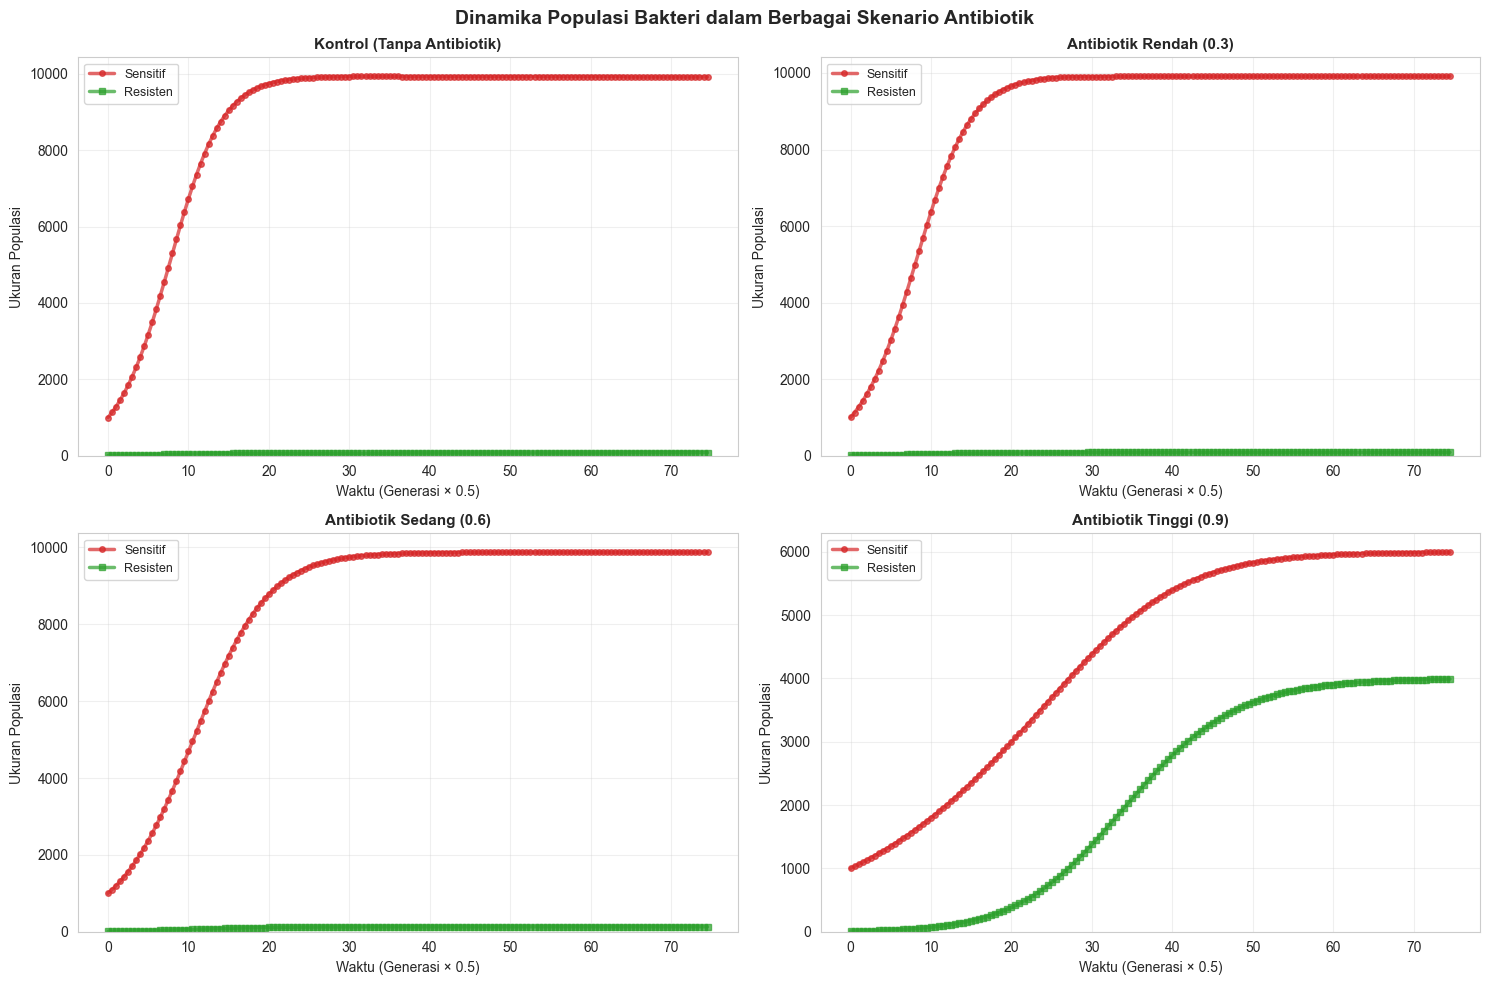

✓ Grafik dinamika populasi berhasil dibuat


In [56]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Dinamika Populasi Bakteri dalam Berbagai Skenario Antibiotik', fontsize=14, fontweight='bold')

scenarios = [
    (df_control, 'Kontrol (Tanpa Antibiotik)', axes[0, 0]),
    (df_low_ab, 'Antibiotik Rendah (0.3)', axes[0, 1]),
    (df_med_ab, 'Antibiotik Sedang (0.6)', axes[1, 0]),
    (df_high_ab, 'Antibiotik Tinggi (0.9)', axes[1, 1])
]

for df, title, ax in scenarios:
    ax.plot(df['time'], df['sensitive'], label='Sensitif', linewidth=2.5, color='#d62728', marker='o', markersize=4, alpha=0.7)
    ax.plot(df['time'], df['resistant'], label='Resisten', linewidth=2.5, color='#2ca02c', marker='s', markersize=4, alpha=0.7)
    
    ax.set_xlabel('Waktu (Generasi × 0.5)', fontsize=10)
    ax.set_ylabel('Ukuran Populasi', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('populasi_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafik dinamika populasi berhasil dibuat")

### 7.2 Frekuensi Alel Resisten Seiring Waktu

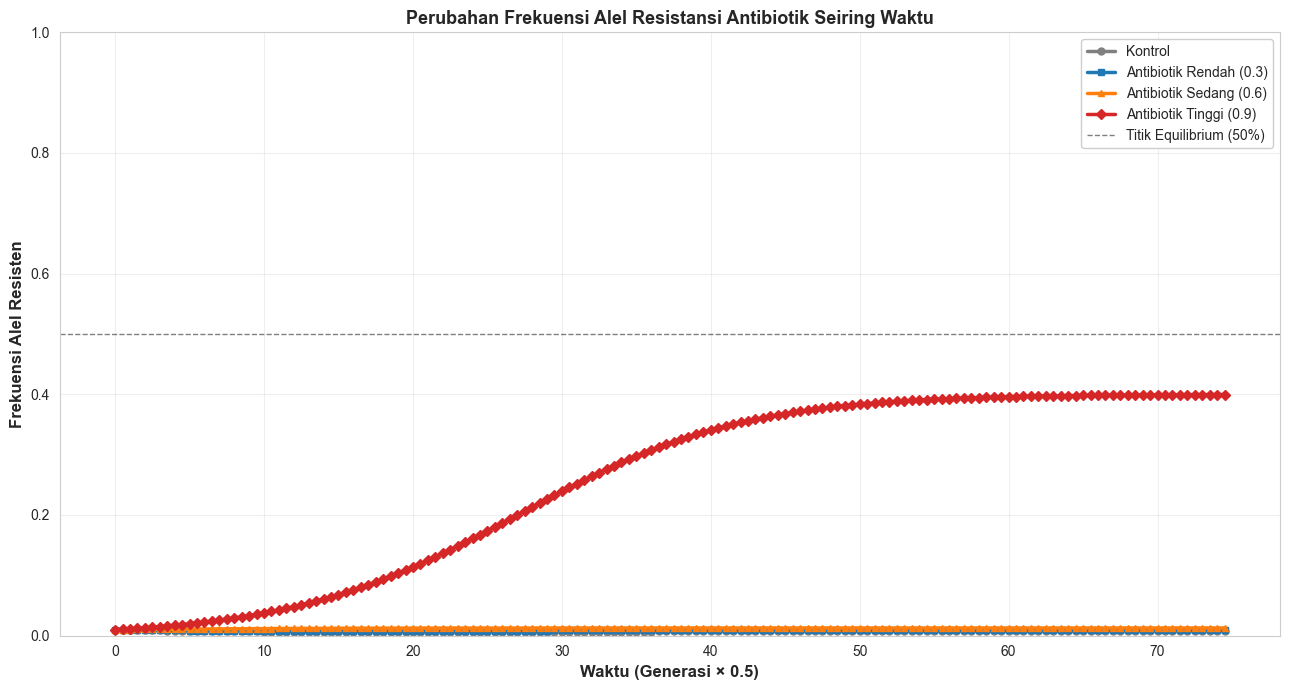

✓ Grafik frekuensi alel berhasil dibuat


In [57]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(df_control['time'], df_control['freq_resistant'], label='Kontrol', linewidth=2.5, marker='o', markersize=5, color='gray')
ax.plot(df_low_ab['time'], df_low_ab['freq_resistant'], label='Antibiotik Rendah (0.3)', linewidth=2.5, marker='s', markersize=5, color='#1f77b4')
ax.plot(df_med_ab['time'], df_med_ab['freq_resistant'], label='Antibiotik Sedang (0.6)', linewidth=2.5, marker='^', markersize=5, color='#ff7f0e')
ax.plot(df_high_ab['time'], df_high_ab['freq_resistant'], label='Antibiotik Tinggi (0.9)', linewidth=2.5, marker='D', markersize=5, color='#d62728')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Titik Equilibrium (50%)')
ax.set_xlabel('Waktu (Generasi × 0.5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frekuensi Alel Resisten', fontsize=12, fontweight='bold')
ax.set_title('Perubahan Frekuensi Alel Resistansi Antibiotik Seiring Waktu', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('allele_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafik frekuensi alel berhasil dibuat")

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(df_control['time'], df_control['total'], label='Kontrol', linewidth=2.5, marker='o', markersize=5)
ax.plot(df_low_ab['time'], df_low_ab['total'], label='Antibiotik Rendah (0.3)', linewidth=2.5, marker='s', markersize=5)
ax.plot(df_med_ab['time'], df_med_ab['total'], label='Antibiotik Sedang (0.6)', linewidth=2.5, marker='^', markersize=5)
ax.plot(df_high_ab['time'], df_high_ab['total'], label='Antibiotik Tinggi (0.9)', linewidth=2.5, marker='D', markersize=5)

ax.axhline(y=10000, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Carrying Capacity (K=10000)')
ax.set_xlabel('Waktu (Generasi × 0.5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Ukuran Populasi', fontsize=12, fontweight='bold')
ax.set_title('Pertumbuhan Total Populasi Bakteri', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('total_population.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafik total populasi berhasil dibuat")

### 7.4 Stacked Area Plot: Komposisi Populasi

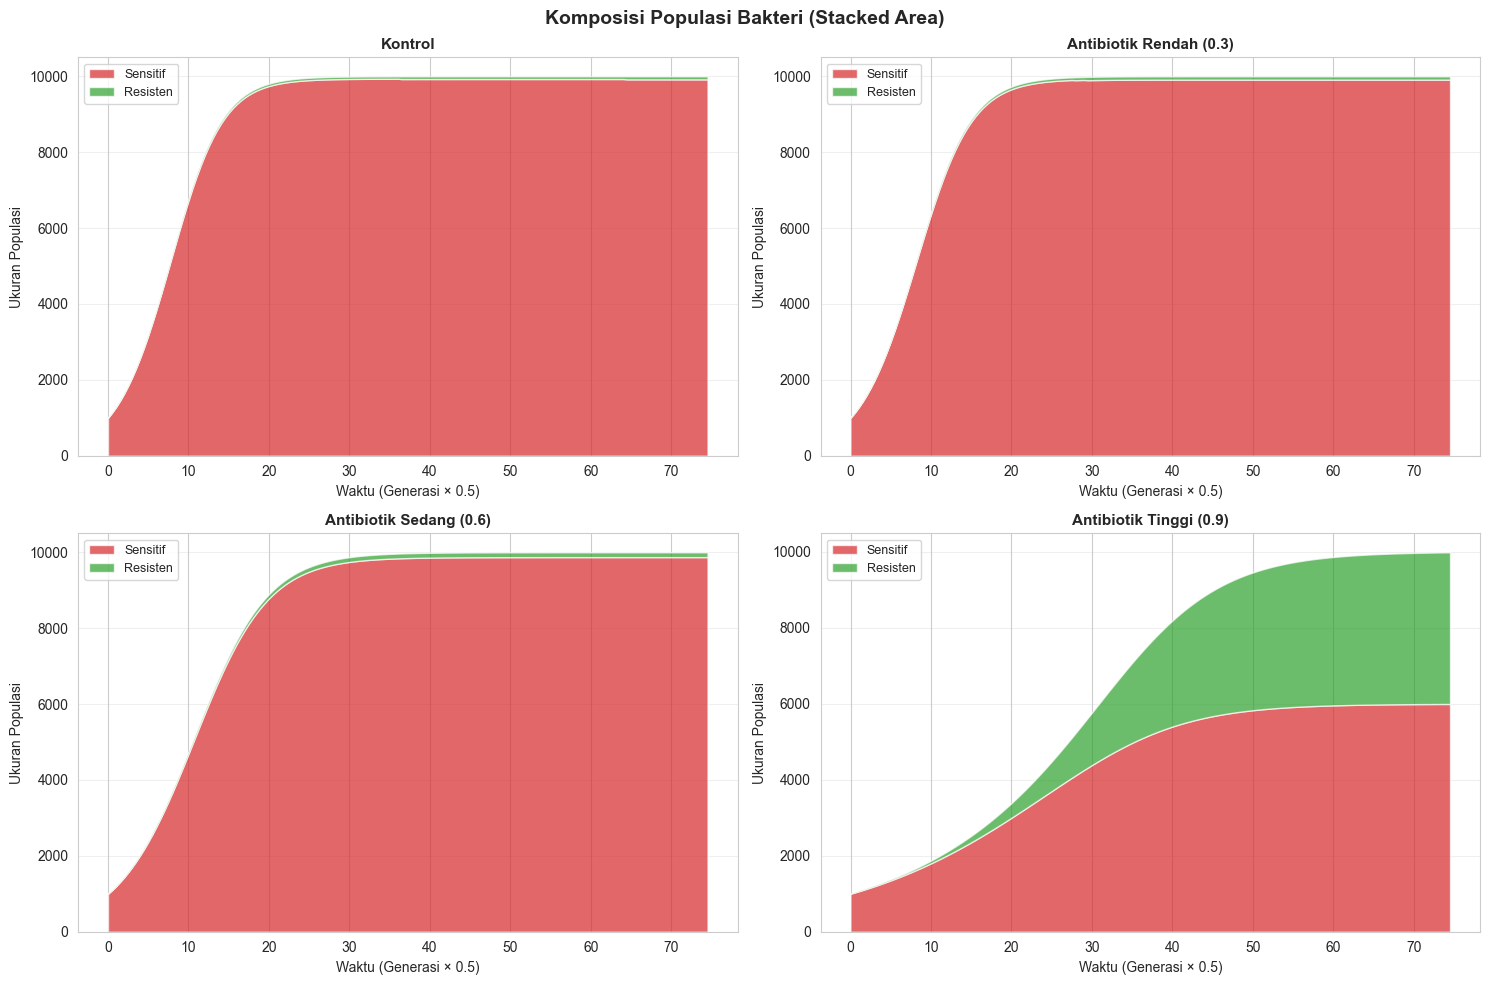

✓ Grafik komposisi populasi berhasil dibuat


In [58]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Komposisi Populasi Bakteri (Stacked Area)', fontsize=14, fontweight='bold')

scenarios = [
    (df_control, 'Kontrol', axes[0, 0]),
    (df_low_ab, 'Antibiotik Rendah (0.3)', axes[0, 1]),
    (df_med_ab, 'Antibiotik Sedang (0.6)', axes[1, 0]),
    (df_high_ab, 'Antibiotik Tinggi (0.9)', axes[1, 1])
]

for df, title, ax in scenarios:
    ax.stackplot(df['time'], df['sensitive'], df['resistant'],
                labels=['Sensitif', 'Resisten'],
                colors=['#d62728', '#2ca02c'],
                alpha=0.7)
    
    ax.set_xlabel('Waktu (Generasi × 0.5)', fontsize=10)
    ax.set_ylabel('Ukuran Populasi', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('population_composition.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafik komposisi populasi berhasil dibuat")

## 8. ANALISIS STATISTIK LANJUTAN

### 8.1 Kecepatan Perubahan Frekuensi Alel (Rate of Allele Frequency Change)

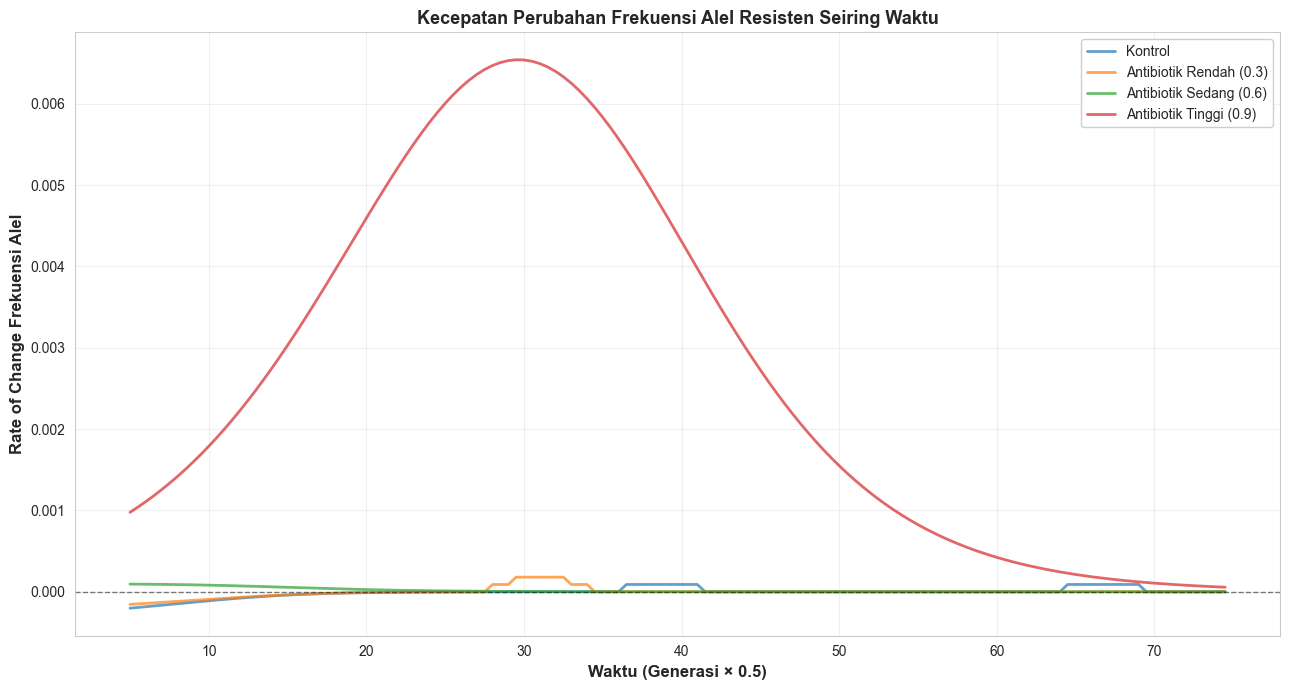

✓ Analisis rate of change berhasil dibuat


In [59]:
def calculate_rate_of_change(df, window_size=10):
    """
    Hitung rate of change dari frekuensi alel menggunakan moving average.
    """
    rate_of_change = df['freq_resistant'].diff(window_size) / window_size
    return rate_of_change

# Hitung rate of change untuk setiap skenario
df_control['rate_of_change'] = calculate_rate_of_change(df_control)
df_low_ab['rate_of_change'] = calculate_rate_of_change(df_low_ab)
df_med_ab['rate_of_change'] = calculate_rate_of_change(df_med_ab)
df_high_ab['rate_of_change'] = calculate_rate_of_change(df_high_ab)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(df_control['time'], df_control['rate_of_change'], label='Kontrol', linewidth=2, alpha=0.7)
ax.plot(df_low_ab['time'], df_low_ab['rate_of_change'], label='Antibiotik Rendah (0.3)', linewidth=2, alpha=0.7)
ax.plot(df_med_ab['time'], df_med_ab['rate_of_change'], label='Antibiotik Sedang (0.6)', linewidth=2, alpha=0.7)
ax.plot(df_high_ab['time'], df_high_ab['rate_of_change'], label='Antibiotik Tinggi (0.9)', linewidth=2, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Waktu (Generasi × 0.5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Rate of Change Frekuensi Alel', fontsize=12, fontweight='bold')
ax.set_title('Kecepatan Perubahan Frekuensi Alel Resisten Seiring Waktu', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rate_of_change.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Analisis rate of change berhasil dibuat")

### 8.2 Statistik Deskriptif untuk Setiap Skenario

In [60]:
scenarios_stats = {
    'Kontrol': df_control,
    'Antibiotik Rendah': df_low_ab,
    'Antibiotik Sedang': df_med_ab,
    'Antibiotik Tinggi': df_high_ab
}

print("\n" + "="*120)
print("STATISTIK DESKRIPTIF FREKUENSI ALEL RESISTEN")
print("="*120)

for scenario_name, df in scenarios_stats.items():
    freq = df['freq_resistant']
    print(f"\n{scenario_name}:")
    print(f"  Mean:     {freq.mean():.6f}")
    print(f"  Std Dev:  {freq.std():.6f}")
    print(f"  Min:      {freq.min():.6f}")
    print(f"  Max:      {freq.max():.6f}")
    print(f"  Median:   {freq.median():.6f}")
    print(f"  Q1 (25%): {freq.quantile(0.25):.6f}")
    print(f"  Q3 (75%): {freq.quantile(0.75):.6f}")

print("\n" + "="*120)


STATISTIK DESKRIPTIF FREKUENSI ALEL RESISTEN

Kontrol:
  Mean:     0.007122
  Std Dev:  0.000775
  Min:      0.006261
  Max:      0.009901
  Median:   0.007161
  Q1 (25%): 0.006320
  Q3 (75%): 0.007161

Antibiotik Rendah:
  Mean:     0.008269
  Std Dev:  0.000765
  Min:      0.006920
  Max:      0.009901
  Median:   0.008720
  Q1 (25%): 0.007580
  Q3 (75%): 0.008720

Antibiotik Sedang:
  Mean:     0.012320
  Std Dev:  0.000662
  Min:      0.009901
  Max:      0.012645
  Median:   0.012642
  Q1 (25%): 0.012431
  Q3 (75%): 0.012645

Antibiotik Tinggi:
  Mean:     0.254194
  Std Dev:  0.147657
  Min:      0.009901
  Max:      0.399664
  Median:   0.319086
  Q1 (25%): 0.099627
  Q3 (75%): 0.392708



### 8.3 Model Fitting: Fungsi Logaritmik untuk Frekuensi Alel

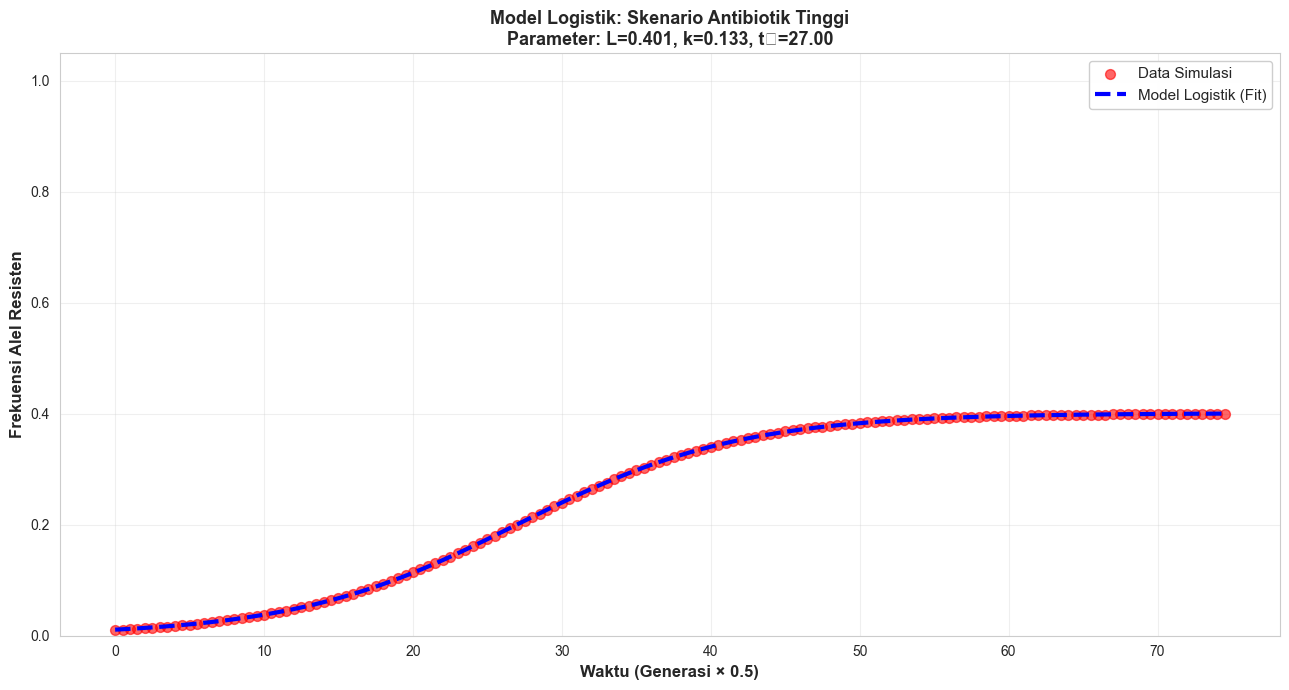

✓ Model logistik berhasil di-fit

Parameter Model Logistik untuk Antibiotik Tinggi:
  L (Max Value):     0.400895
  k (Steepness):     0.133151
  t₀ (Inflection):   27.003853


In [61]:
# Definisikan model logistik S-curve
def logistic_model(t, L, k, t0):
    """
    Model logistik (sigmoid) untuk menggambarkan perubahan frekuensi alel.
    
    L: kurva maximum value (typically 1 for allele frequency)
    k: steepness of the curve
    t0: time of maximum growth
    """
    return L / (1 + np.exp(-k * (t - t0)))

# Fit untuk skenario dengan antibiotik tinggi
try:
    popt_high, _ = curve_fit(logistic_model, df_high_ab['time'], df_high_ab['freq_resistant'],
                            p0=[1, 0.1, 50], maxfev=5000)
    
    # Generate fitted curve
    t_fit = np.linspace(0, df_high_ab['time'].max(), 200)
    freq_fit = logistic_model(t_fit, *popt_high)
    
    fig, ax = plt.subplots(figsize=(13, 7))
    
    ax.scatter(df_high_ab['time'], df_high_ab['freq_resistant'], label='Data Simulasi', 
              s=50, alpha=0.6, color='red')
    ax.plot(t_fit, freq_fit, label=f'Model Logistik (Fit)',
           linewidth=3, color='blue', linestyle='--')
    
    ax.set_xlabel('Waktu (Generasi × 0.5)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frekuensi Alel Resisten', fontsize=12, fontweight='bold')
    ax.set_title(f'Model Logistik: Skenario Antibiotik Tinggi\nParameter: L={popt_high[0]:.3f}, k={popt_high[1]:.3f}, t₀={popt_high[2]:.2f}',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.savefig('logistic_model_fit.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Model logistik berhasil di-fit")
    print(f"\nParameter Model Logistik untuk Antibiotik Tinggi:")
    print(f"  L (Max Value):     {popt_high[0]:.6f}")
    print(f"  k (Steepness):     {popt_high[1]:.6f}")
    print(f"  t₀ (Inflection):   {popt_high[2]:.6f}")
    
except Exception as e:
    print(f"Model fitting error: {e}")

### 8.4 Analisis Hubungan Konsentrasi Antibiotik vs Frekuensi Alel Akhir


Menjalankan multiple simulations dengan berbagai konsentrasi...

Konsentrasi: 0.0 | Frekuensi Akhir: 0.0063 | Pop. Resisten: 62
Konsentrasi: 0.1 | Frekuensi Akhir: 0.0072 | Pop. Resisten: 71
Konsentrasi: 0.2 | Frekuensi Akhir: 0.0063 | Pop. Resisten: 63
Konsentrasi: 0.3 | Frekuensi Akhir: 0.0075 | Pop. Resisten: 74
Konsentrasi: 0.4 | Frekuensi Akhir: 0.0080 | Pop. Resisten: 79
Konsentrasi: 0.5 | Frekuensi Akhir: 0.0098 | Pop. Resisten: 98
Konsentrasi: 0.6 | Frekuensi Akhir: 0.0111 | Pop. Resisten: 110
Konsentrasi: 0.7 | Frekuensi Akhir: 0.0155 | Pop. Resisten: 154
Konsentrasi: 0.8 | Frekuensi Akhir: 0.0402 | Pop. Resisten: 402
Konsentrasi: 0.9 | Frekuensi Akhir: 0.2789 | Pop. Resisten: 2782
Konsentrasi: 1.0 | Frekuensi Akhir: 0.8442 | Pop. Resisten: 8441


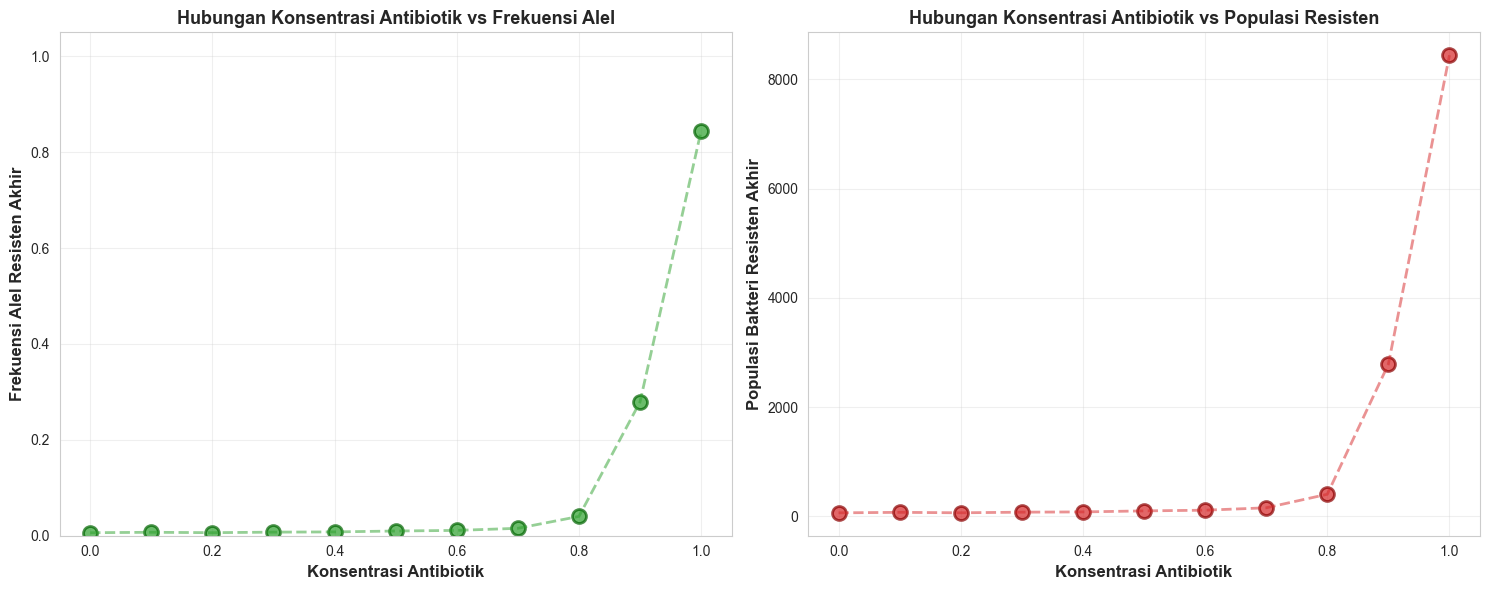


✓ Analisis hubungan konsentrasi-frekuensi berhasil dibuat


In [62]:
# Jalankan multiple simulations dengan berbagai konsentrasi antibiotik
concentrations = np.linspace(0, 1.0, 11)
final_frequencies = []
final_populations_resistant = []

print("\nMenjalankan multiple simulations dengan berbagai konsentrasi...\n")

for conc in concentrations:
    pop = BacterialPopulation(
        initial_pop_sensitive=1000,
        initial_pop_resistant=10,
        antibiotic_concentration=conc,
        selection_coefficient=min(0.95, conc)
    )
    pop.simulate(generations=150, dt=0.5)
    df_result = pop.get_dataframe()
    
    final_frequencies.append(df_result['freq_resistant'].iloc[-1])
    final_populations_resistant.append(df_result['resistant'].iloc[-1])
    
    print(f"Konsentrasi: {conc:.1f} | Frekuensi Akhir: {df_result['freq_resistant'].iloc[-1]:.4f} | Pop. Resisten: {int(df_result['resistant'].iloc[-1])}")

# Visualisasi hubungan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Frekuensi vs Konsentrasi
ax1.scatter(concentrations, final_frequencies, s=100, alpha=0.7, color='#2ca02c', edgecolors='darkgreen', linewidth=2)
ax1.plot(concentrations, final_frequencies, linestyle='--', linewidth=2, color='#2ca02c', alpha=0.5)
ax1.set_xlabel('Konsentrasi Antibiotik', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frekuensi Alel Resisten Akhir', fontsize=12, fontweight='bold')
ax1.set_title('Hubungan Konsentrasi Antibiotik vs Frekuensi Alel', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Populasi Resisten vs Konsentrasi
ax2.scatter(concentrations, final_populations_resistant, s=100, alpha=0.7, color='#d62728', edgecolors='darkred', linewidth=2)
ax2.plot(concentrations, final_populations_resistant, linestyle='--', linewidth=2, color='#d62728', alpha=0.5)
ax2.set_xlabel('Konsentrasi Antibiotik', fontsize=12, fontweight='bold')
ax2.set_ylabel('Populasi Bakteri Resisten Akhir', fontsize=12, fontweight='bold')
ax2.set_title('Hubungan Konsentrasi Antibiotik vs Populasi Resisten', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('concentration_response.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Analisis hubungan konsentrasi-frekuensi berhasil dibuat")

# Analisis Komputasi Evolusi Resistansi Antibiotik
## melalui Mekanisme Seleksi Alam

**Topik**: Evolution and Natural Selection


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
np.random.seed(42)
print('✓ Semua pustaka berhasil diimport')
print('✓ Konfigurasi visualisasi selesai')


✓ Semua pustaka berhasil diimport
✓ Konfigurasi visualisasi selesai


## 1. LANDASAN BIOLOGI

### Mekanisme Resistansi
- **SS (Susceptible)**: Rentan, fitness tinggi
- **SR (Heterozygous)**: Intermediate
- **RR (Resistant)**: Sangat resistan, fitness rendah

### Fitness Cost
- Mekanisme resistansi mengurangi growth rate (5-30%)
- Tanpa antibiotik: alel resistan menurun
- Dengan antibiotik: alel resistan meningkat


In [66]:
class BacterialPopulationParameters:
    def __init__(self):
        self.initial_population = 10000
        self.initial_resistance_freq = 0.01  
        self.fitness_cost = 0.05            
        self.selection_coefficient = 0.2  
        self.max_generations = 200
        self.antibiotic_exposure = False
    
    def display_parameters(self):
        print(f'Initial Resistance Freq: {self.initial_resistance_freq*100:.1f}%')
        print(f'Fitness Cost (no AB):    {self.fitness_cost*100:.1f}%')
        print(f'Selection Coefficient:   {self.selection_coefficient}')

params = BacterialPopulationParameters()
params.display_parameters()


Initial Resistance Freq: 1.0%
Fitness Cost (no AB):    5.0%
Selection Coefficient:   0.2


In [67]:
class PopulationGeneticsModel:
    def __init__(self, params):
        self.params = params
        self.p_history = []
        self.generations = []
    
    def calculate_fitness(self, antibiotic_present):
        """
        ✅ PERBAIKAN: Fitness sekarang dinamis berdasarkan parameter
        """
        if antibiotic_present:
            # Saat ada antibiotik:
            # - SS (sensitif) = 1 - selection_coeff
            # - RR (resisten) = 1.0 (tidak terpengaruh)
            w_SS = 1.0 - self.params.selection_coefficient  # GUNAKAN selection_coefficient!
            w_RR = 1.0
            w_SR = (w_SS + w_RR) / 2
        else:
            # Tanpa antibiotik:
            # - SS (sensitif) = 1.0 (normal)
            # - RR (resisten) = 1 - fitness_cost (ada penalty)
            w_SS = 1.0
            w_RR = 1.0 - self.params.fitness_cost  # GUNAKAN fitness_cost!
            w_SR = (w_SS + w_RR) / 2
        
        return w_SS, w_SR, w_RR
    
    def allele_frequency_change(self, p_t, antibiotic_present):
        """
        ✅ PERBAIKAN: Formula Hardy-Weinberg selection yang benar
        p_next = [p*w_AA + (1-p)*w_Aa*p] / w_bar
        """
        w_SS, w_SR, w_RR = self.calculate_fitness(antibiotic_present)
        q_t = 1 - p_t
        
        # Mean fitness
        w_bar = p_t**2 * w_RR + 2*p_t*q_t * w_SR + q_t**2 * w_SS
        
        # Frekuensi alel R generasi berikutnya
        if w_bar > 0:
            p_next = (p_t**2 * w_RR + p_t * q_t * w_SR) / w_bar
        else:
            p_next = 0
        
        return np.clip(p_next, 0, 1)
    
    def run_simulation(self, antibiotic_schedule):
        p = self.params.initial_resistance_freq
        self.p_history = [p]
        self.generations = [0]
        
        for gen in range(1, self.params.max_generations + 1):
            antibiotic_present = antibiotic_schedule[gen-1]
            p = self.allele_frequency_change(p, antibiotic_present)
            
            self.p_history.append(p)
            self.generations.append(gen)
            
            if p >= 0.999 or p <= 0.001:
                break
        
        return self.p_history, self.generations

model = PopulationGeneticsModel(params)
print('✓ PopulationGeneticsModel initialized')


✓ PopulationGeneticsModel initialized


In [68]:
print('\n' + '='*70)
print('SKENARIO 1: TANPA ANTIBIOTIK')
print('='*70)
params1 = BacterialPopulationParameters()
params1.antibiotic_exposure = False
model1 = PopulationGeneticsModel(params1)
schedule1 = [False] * params1.max_generations
p_hist1, gen1 = model1.run_simulation(schedule1)
print(f'Simulasi selesai ({len(gen1)} generasi): p={p_hist1[-1]:.4e}\n')

print('='*70)
print('SKENARIO 2: ANTIBIOTIK BERKELANJUTAN')
print('='*70)
params2 = BacterialPopulationParameters()
params2.antibiotic_exposure = True
model2 = PopulationGeneticsModel(params2)
schedule2 = [True] * params2.max_generations
p_hist2, gen2 = model2.run_simulation(schedule2)
print(f'Simulasi selesai ({len(gen2)} generasi): p={p_hist2[-1]:.4e}\n')

print('='*70)
print('SKENARIO 3: INTERMITTENT')
print('='*70)
params3 = BacterialPopulationParameters()
model3 = PopulationGeneticsModel(params3)
schedule3 = [(i // 30) % 2 == 0 for i in range(params3.max_generations)]
p_hist3, gen3 = model3.run_simulation(schedule3)
print(f'Simulasi selesai ({len(gen3)} generasi): p={p_hist3[-1]:.4e}\n')

print('='*70)
print('SKENARIO 4: HIGH FITNESS COST')
print('='*70)
params4 = BacterialPopulationParameters()
params4.antibiotic_exposure = True
params4.fitness_cost = 0.30
model4 = PopulationGeneticsModel(params4)
schedule4 = [True] * params4.max_generations
p_hist4, gen4 = model4.run_simulation(schedule4)
print(f'Simulasi selesai ({len(gen4)} generasi): p={p_hist4[-1]:.4e}\n')

print('='*70)
print('SKENARIO 5: WEAK SELECTION')
print('='*70)
params5 = BacterialPopulationParameters()
params5.antibiotic_exposure = True
params5.selection_coefficient = 0.05
model5 = PopulationGeneticsModel(params5)
schedule5 = [True] * params5.max_generations
p_hist5, gen5 = model5.run_simulation(schedule5)
print(f'Simulasi selesai ({len(gen5)} generasi): p={p_hist5[-1]:.4e}\n')

print('✓ Semua simulasi selesai')



SKENARIO 1: TANPA ANTIBIOTIK
Simulasi selesai (93 generasi): p=9.8234e-04

SKENARIO 2: ANTIBIOTIK BERKELANJUTAN
Simulasi selesai (106 generasi): p=9.9905e-01

SKENARIO 3: INTERMITTENT
Simulasi selesai (201 generasi): p=9.9483e-01

SKENARIO 4: HIGH FITNESS COST
Simulasi selesai (106 generasi): p=9.9905e-01

SKENARIO 5: WEAK SELECTION
Simulasi selesai (201 generasi): p=6.3967e-01

✓ Semua simulasi selesai


In [69]:
scenarios = [
    ('Skenario 1: No AB', gen1, p_hist1),
    ('Skenario 2: Continuous', gen2, p_hist2),
    ('Skenario 3: Intermittent', gen3, p_hist3),
    ('Skenario 4: High Cost', gen4, p_hist4),
    ('Skenario 5: Weak Selection', gen5, p_hist5),
]

print('\n' + '='*80)
print('ANALISIS HASIL SIMULASI')
print('='*80)

for scenario_name, generations, p_hist in scenarios:
    final_p = p_hist[-1]
    init_p = p_hist[0]
    print(f'\n{scenario_name}:')
    print(f'  Initial p: {init_p:.4e}, Final p: {final_p:.4f}')
    print(f'  Generations: {len(generations)}')

print('\n✓ Analisis selesai')



ANALISIS HASIL SIMULASI

Skenario 1: No AB:
  Initial p: 1.0000e-02, Final p: 0.0010
  Generations: 93

Skenario 2: Continuous:
  Initial p: 1.0000e-02, Final p: 0.9991
  Generations: 106

Skenario 3: Intermittent:
  Initial p: 1.0000e-02, Final p: 0.9948
  Generations: 201

Skenario 4: High Cost:
  Initial p: 1.0000e-02, Final p: 0.9991
  Generations: 106

Skenario 5: Weak Selection:
  Initial p: 1.0000e-02, Final p: 0.6397
  Generations: 201

✓ Analisis selesai


✓ Visualization saved


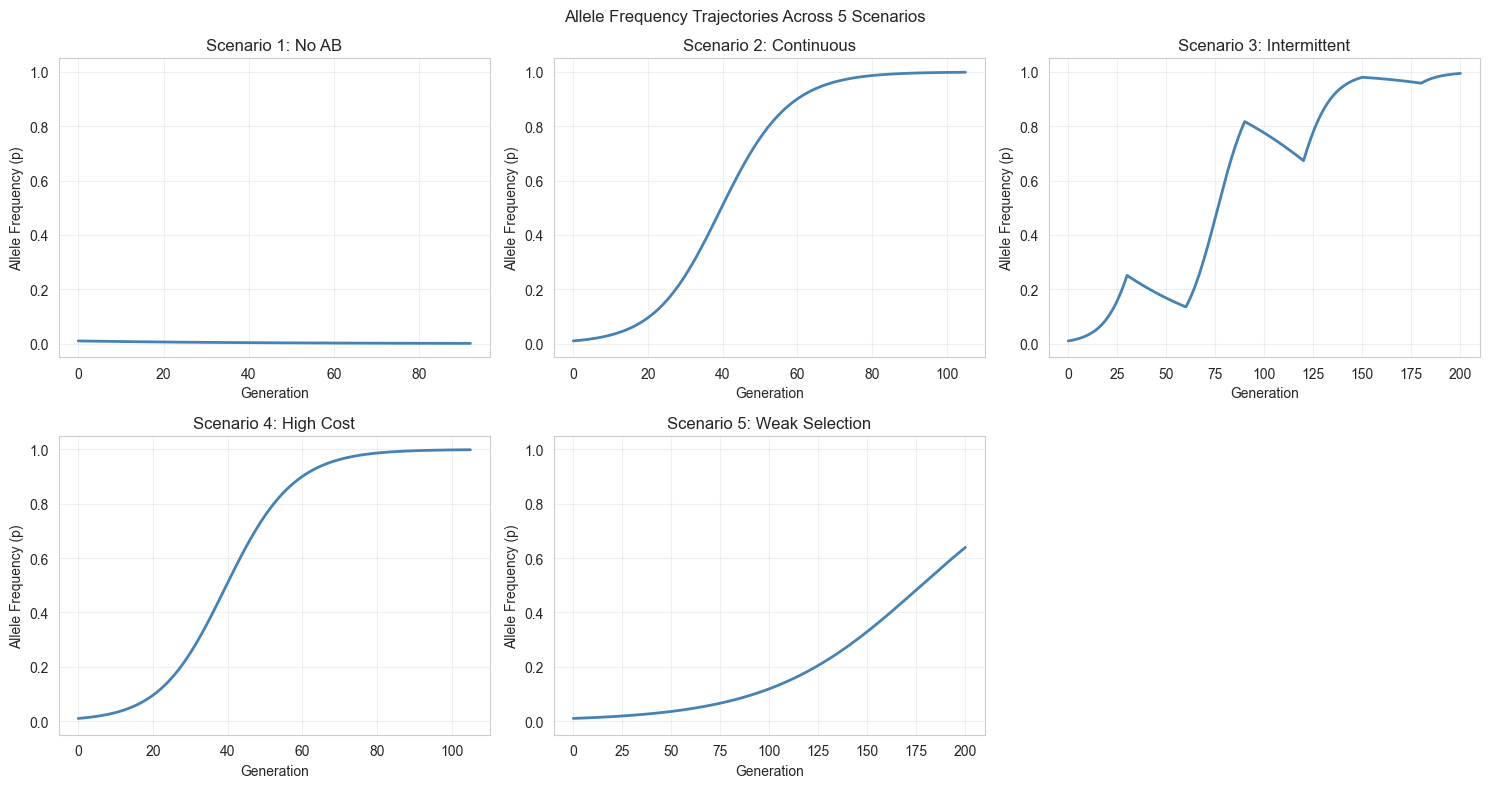

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Allele Frequency Trajectories Across 5 Scenarios')

scenarios_plot = [
    (gen1, p_hist1, 'Scenario 1: No AB'),
    (gen2, p_hist2, 'Scenario 2: Continuous'),
    (gen3, p_hist3, 'Scenario 3: Intermittent'),
    (gen4, p_hist4, 'Scenario 4: High Cost'),
    (gen5, p_hist5, 'Scenario 5: Weak Selection'),
]

for idx, (ax, (gen, p_hist, title)) in enumerate(zip(axes.flat, scenarios_plot)):
    ax.plot(gen, p_hist, linewidth=2, color='steelblue')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Allele Frequency (p)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('/Users/aliyaharta/Documents/GitHub/TubesKDSKel5/visualization.png')
print('✓ Visualization saved')
plt.show()
